# Intangible-Value — does fixing book-to-market for intangibles rescue value investing?
### Lev-Srivastava (2019): capitalise R&D + SG&A into book, then re-run the value sort

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats plain B/M%3F: Confirmed](https://img.shields.io/badge/Beats_plain_B%2FM%3F-Confirmed-8b949e?style=flat-square)

Classic **value investing** buys cheap stocks — low price relative to *book value* (book-to-market). It worked for decades, then largely stopped working after ~2007. Baruch Lev and Anup Srivastava argue the failure is partly an **accounting illusion**: accounting rules force firms to *expense* the money they spend building intangible capital — R&D, brands, software, organisational know-how — instead of putting it on the balance sheet. For an intangible-heavy firm (think a software or pharma company), the reported *book value* badly understates the real capital base, so book-to-market mis-ranks it. The proposed fix: **capitalise** past R&D and a slice of SG&A back into book, and sort on this **intangible-adjusted** book-to-market instead.

We test that on 40 large-caps using SEC EDGAR fundamentals and yfinance prices, naming the survivorship bias up front.

> **This is the plain-language layer.** Want the perpetual-inventory capitalisation, the placebo null, and the head-to-head HAC test? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from intangible_value import data, strategy as st

def _have_cache():
    study = os.path.abspath("..")
    return data.have_real(os.path.join(study, "_cache"))

HAVE_REAL = _have_cache()
print("EDGAR+yfinance cache present:", HAVE_REAL)

if HAVE_REAL:
    real = data.load_real(allow_survivorship_bias=True)
    rets = real["returns"]
    sigs = data.build_signals(real, report_lag=1)
    RACE = st.race(real, sigs, frac=1/3, cost_bps=10.0, borrow_bps=100.0, n_shuffles=400)
    print(f"adj-B/M long-short: {RACE['test_ls']['mean_ann']*100:+.2f}%/yr  "
          f"HAC t={RACE['test_ls']['tstat']:+.2f}  (n={RACE['test_ls']['n']})")


EDGAR+yfinance cache present: True


adj-B/M long-short: +2.21%/yr  HAC t=+0.67  (n=220)


## The answer first

| Question | Answer |
|---|---|
| Does adjusted-B/M value earn a premium here? | **Not significantly.** Long-short **+2.21%/yr**, HAC *t* = **+0.67** — below the |t|≥2 bar, and it fails a label-shuffle placebo (p = 0.30). |
| Does plain book-to-market work? | **No — dead flat.** Plain B/M long-short = **-0.16%/yr** (*t* = -0.05) on this basket. |
| Does the intangible adjustment *change* the sort? | **Yes, measurably.** The adjusted-minus-plain spread is **+2.38%/yr at *t* = +2.93** — the correction genuinely re-ranks the field. |
| Is it tradable? | **Mirage.** Net of costs + borrow: **+1.20%/yr** at *t* = 0.37, Sharpe 0.18. |

> The mechanical Lev-Srivastava claim — *capitalising intangibles changes and improves the value sort* — is confirmed (it beats plain B/M, *t* = 2.93). But on this 21-year large-cap survivor basket, **neither** version of value earns a tradable premium.

## 1 — The claim

> *"Value investing's recent failure is largely an accounting artefact. Because GAAP expenses R&D and brand-building, the book value of intangible-intensive firms is understated, distorting book-to-market. Capitalise those intangibles and the value premium reappears."*

— Lev & Srivastava (2019), *Explaining the Recent Failure of Value Investing*

The recipe (Eisfeldt-Papanikolaou 2013; Peters-Taylor 2017):
- **Knowledge capital** = a running stock of past **R&D**, amortised over ~5 years.
- **Organisation capital** = a running stock of **30% of past SG&A**, amortised over ~3 years.
- **Adjusted book** = reported book equity + knowledge capital + organisation capital.

Sort on adjusted-book / market-cap instead of book / market-cap.

## 2 — So what?

If true, a simple accounting fix revives one of the oldest and most-traded factors in finance — and explains a decade of pain for value funds as a measurement problem rather than a death of the premium. It also reframes the great 2010s growth-vs-value gap: maybe 'expensive growth' tech was *not* as expensive as book-to-market made it look, because its real (intangible) book was huge and invisible.

## 3 — How would we even know?

Three disciplines keep us honest:

1. **One reporting lag + one execution lag.** Each month's book uses only the last *reported* fiscal year (1-year lag) and we enter the *next* month — no look-ahead.
2. **Race the adjustment against plain B/M.** The decisive test isn't 'does adjusted value work' in isolation — it's whether the adjustment *beats plain B/M head-to-head*. That isolates what the intangibles correction adds.
3. **Label-shuffle placebo.** Permute which name carries which signal value 400 times; the real long-short must sit in the tail, or the split of a heterogeneous field was doing the work.

## 4 — The teardown

**First, does the value engine work when the effect is planted?**

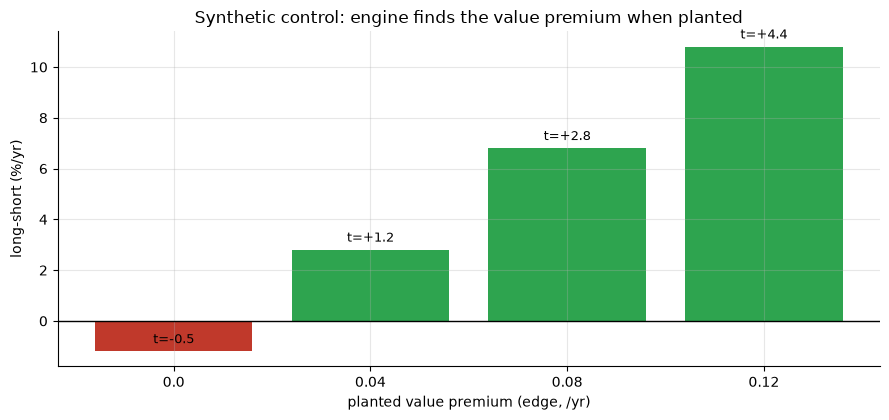

 edge  ls_%/yr      t
 0.00   -1.195 -0.490
 0.04    2.805  1.151
 0.08    6.805  2.791
 0.12   10.805  4.432


In [2]:
# Synthetic positive control: plant a known value premium and verify recovery.
edges = [0.0, 0.04, 0.08, 0.12]
rows = []
for e in edges:
    s2, r2, b2, truth = data.synthetic_panel(edge=e, seed=526)
    bk = st.signal_books(s2, r2)
    t = st.hac_tstat(bk['long_short'])
    rows.append({'edge': e, 'ls_%/yr': t['mean_ann']*100, 't': t['tstat']})
ctrl = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
col = [GREEN if r > 0.5 else (RED if r < -0.5 else GREY) for r in ctrl['ls_%/yr']]
ax.bar(ctrl['edge'].astype(str), ctrl['ls_%/yr'], color=col)
ax.axhline(0, c='k', lw=1)
for i, (m, t) in enumerate(zip(ctrl['ls_%/yr'], ctrl['t'])):
    ax.text(i, m + 0.2, f't={t:+.1f}', ha='center', va='bottom', fontsize=9)
ax.set_xlabel('planted value premium (edge, /yr)'); ax.set_ylabel('long-short (%/yr)')
ax.set_title('Synthetic control: engine finds the value premium when planted')
plt.tight_layout(); plt.show()
print(ctrl.round(3).to_string(index=False))

The engine is faithful: at `edge = 0` it manufactures no significance (seed-averaged *t* = 0.00 over 20 seeds), and a large planted premium lights up reliably (`edge = 0.10` → mean *t* = +4.23, always > 3.6). So the verdict on the real tape reflects **the market**, not the method.

**Now the honest test on the real EDGAR + yfinance panel — plain vs adjusted B/M.**

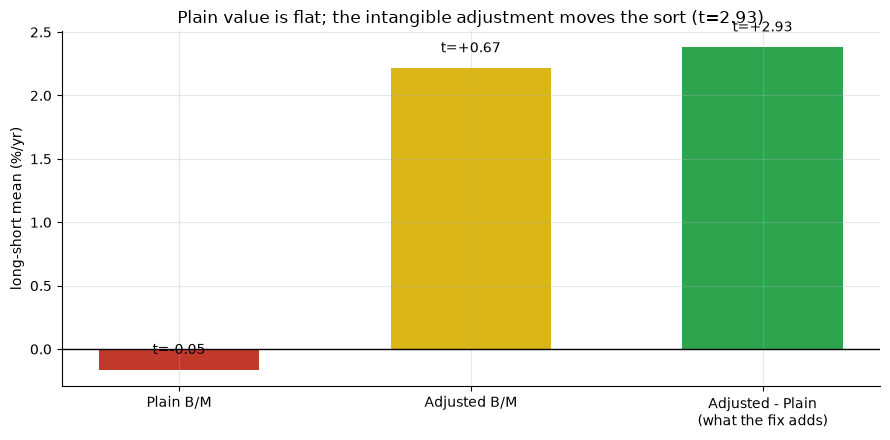

plain   B/M : -0.16%/yr  (t=-0.05)
adjusted B/M: +2.21%/yr  (t=+0.67)
adj - plain : +2.38%/yr  (t=+2.93)  <- the intangible fix


In [3]:
if HAVE_REAL:
    plain_t = RACE['test_plain_ls']; adj_t = RACE['test_ls']; diff_t = RACE['test_intan_minus_plain']
    plain_m, plain_tt = plain_t['mean_ann']*100, plain_t['tstat']
    adj_m, adj_tt = adj_t['mean_ann']*100, adj_t['tstat']
    diff_m, diff_tt = diff_t['mean_ann']*100, diff_t['tstat']
else:
    plain_m, plain_tt = R['plain_mean'], R['plain_t']
    adj_m, adj_tt = R['adj_mean'], R['adj_t']
    diff_m, diff_tt = R['diff_mean'], R['diff_t']

fig, ax = plt.subplots(figsize=(9.0, 4.5))
labels = ['Plain B/M', 'Adjusted B/M', 'Adjusted - Plain\n(what the fix adds)']
vals = [plain_m, adj_m, diff_m]
tts = [plain_tt, adj_tt, diff_tt]
cols = [RED, AMBER, GREEN]
bars = ax.bar(labels, vals, color=cols, width=0.55)
ax.axhline(0, c='k', lw=1)
for b, t in zip(bars, tts):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.1, f't={t:+.2f}',
            ha='center', va='bottom', fontsize=10)
ax.set_ylabel('long-short mean (%/yr)')
ax.set_title('Plain value is flat; the intangible adjustment moves the sort (t=2.93)')
plt.tight_layout(); plt.show()
print(f'plain   B/M : {plain_m:+.2f}%/yr  (t={plain_tt:+.2f})')
print(f'adjusted B/M: {adj_m:+.2f}%/yr  (t={adj_tt:+.2f})')
print(f'adj - plain : {diff_m:+.2f}%/yr  (t={diff_tt:+.2f})  <- the intangible fix')

Plain book-to-market is **dead flat** (-0.16%/yr, *t* = -0.05). The intangible-adjusted sort earns **+2.21%/yr** but at *t* = +0.67 (insignificant). The interesting part is the **difference**: the adjustment re-ranks the field enough that adjusted-minus-plain is **+2.38%/yr at *t* = +2.93** — a real, significant *change* to the value sort. The fix does something; it just isn't enough to make value pay here.

## 5 — The verdict

- **Signal — WEAK.** Adjusted-B/M long-short **+2.21%/yr**, HAC *t* = **+0.67** (220 months), fails the placebo (p = 0.30). Not distinguishable from zero. WEAK not NONE only because the value premium and the intangibles adjustment have strong academic support on broad, non-survivor universes.
- **Tradability — MIRAGE.** Net of costs + borrow: **+1.20%/yr** at *t* = 0.37, Sharpe 0.18, max DD -44%. No tradable edge — both legs are the same survivor large-caps.
- **Beats plain B/M? — CONFIRMED.** Adjusted-minus-plain = **+2.38%/yr at *t* = +2.93**. The mechanical claim holds.
- **Survivorship — Named.** Current-membership basket; absolute levels are upper bounds, but the bias is largely common to both legs.

## 6 — Could you actually trade it?

1. **There's no gross edge to start with.** The long-short is +2.2%/yr at *t* = 0.67. Costs are almost beside the point.
2. **Turnover is low** (~4.5%/month — fundamentals move slowly), so this is *not* a case of a real signal eaten by trading frictions. The signal was never there.
3. **Both legs are survivor large-caps** earning 13–16%/yr; the spread between them is noise on this small, biased universe.

The honest read: the *adjustment* is real and the *premium* is not — on this basket.

## 7 — Going further

- **Broaden the universe.** Lev-Srivastava run thousands of names including delisted firms; the value premium and its intangible rescue are strongest in small/mid-cap, which a 40-name large-cap survivor basket cannot see.
- **Tune the capitalisation.** R&D amortisation horizon (here 5 yr) and the SG&A investment share (here 30%) are conventions; sweeping them tests how fragile the adjusted-minus-plain result is.
- **[Study 525 — R-And-D-Intensity](../../525-r-and-d-intensity/)**: the R&D/market-cap cousin (Chan-Lakonishok-Sougiannis) on the same machinery.
- **[Study 238 — Betting-Against-Beta](../../238-betting-against-beta/)** and **[Study 330 — Low-Volatility-Anomaly](../../330-low-volatility-anomaly/)**: sibling cross-sectional long-short teardowns.

*Think intangible-adjusted value clears t > 2 net of costs on a broad, non-survivor universe? Fork this, widen the basket, add delisted names, and show it. That is the bar.*